# Wrapped geodesics on the flat torus

The flat torus $\mathbb T^2=S^1\times S^1$ can be represented by two angles in
$[-\pi,\pi)$. Its logarithm chooses the shortest wrapped angular difference,

$$
\operatorname{Log}_x(y)=\operatorname{wrap}(y-x),
$$

and the exponential map adds that tangent vector modulo $2\pi$. A shortest
path can therefore cross the edge of the angular coordinate square while
remaining smooth on the torus itself.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from geojax.geometry import Torus

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 240,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

M = Torus(size=2)
x = jnp.array([2.75, 2.45])
y = jnp.array([-2.60, -2.20])
velocity = M.log(x, y)
times = jnp.linspace(0.0, 1.0, 180)
path = jax.vmap(lambda time: M.exp(x, time * velocity))(times)

print("shortest wrapped displacement:", velocity)
print("intrinsic distance:", float(M.dist(x, y)))
print("unwrapped Euclidean difference:", float(jnp.linalg.norm(y - x)))
print("endpoint error:", float(M.dist(path[-1], y)))

shortest wrapped displacement: [0.93318531 1.63318531]
intrinsic distance: 1.8809915111778515
unwrapped Euclidean difference: 7.088370757797591
endpoint error: 4.440892098500626e-16


intrinsic distance: 1.8809915111778515
unwrapped Euclidean difference: 7.088370757797591
endpoint error: 4.440892098500626e-16


## Compare intrinsic and coordinate views

The familiar embedded torus is only a visualization of this flat product
geometry; its induced surface metric is different. It is nevertheless useful
for seeing that the apparent jumps in angular coordinates are not breaks in
the path.

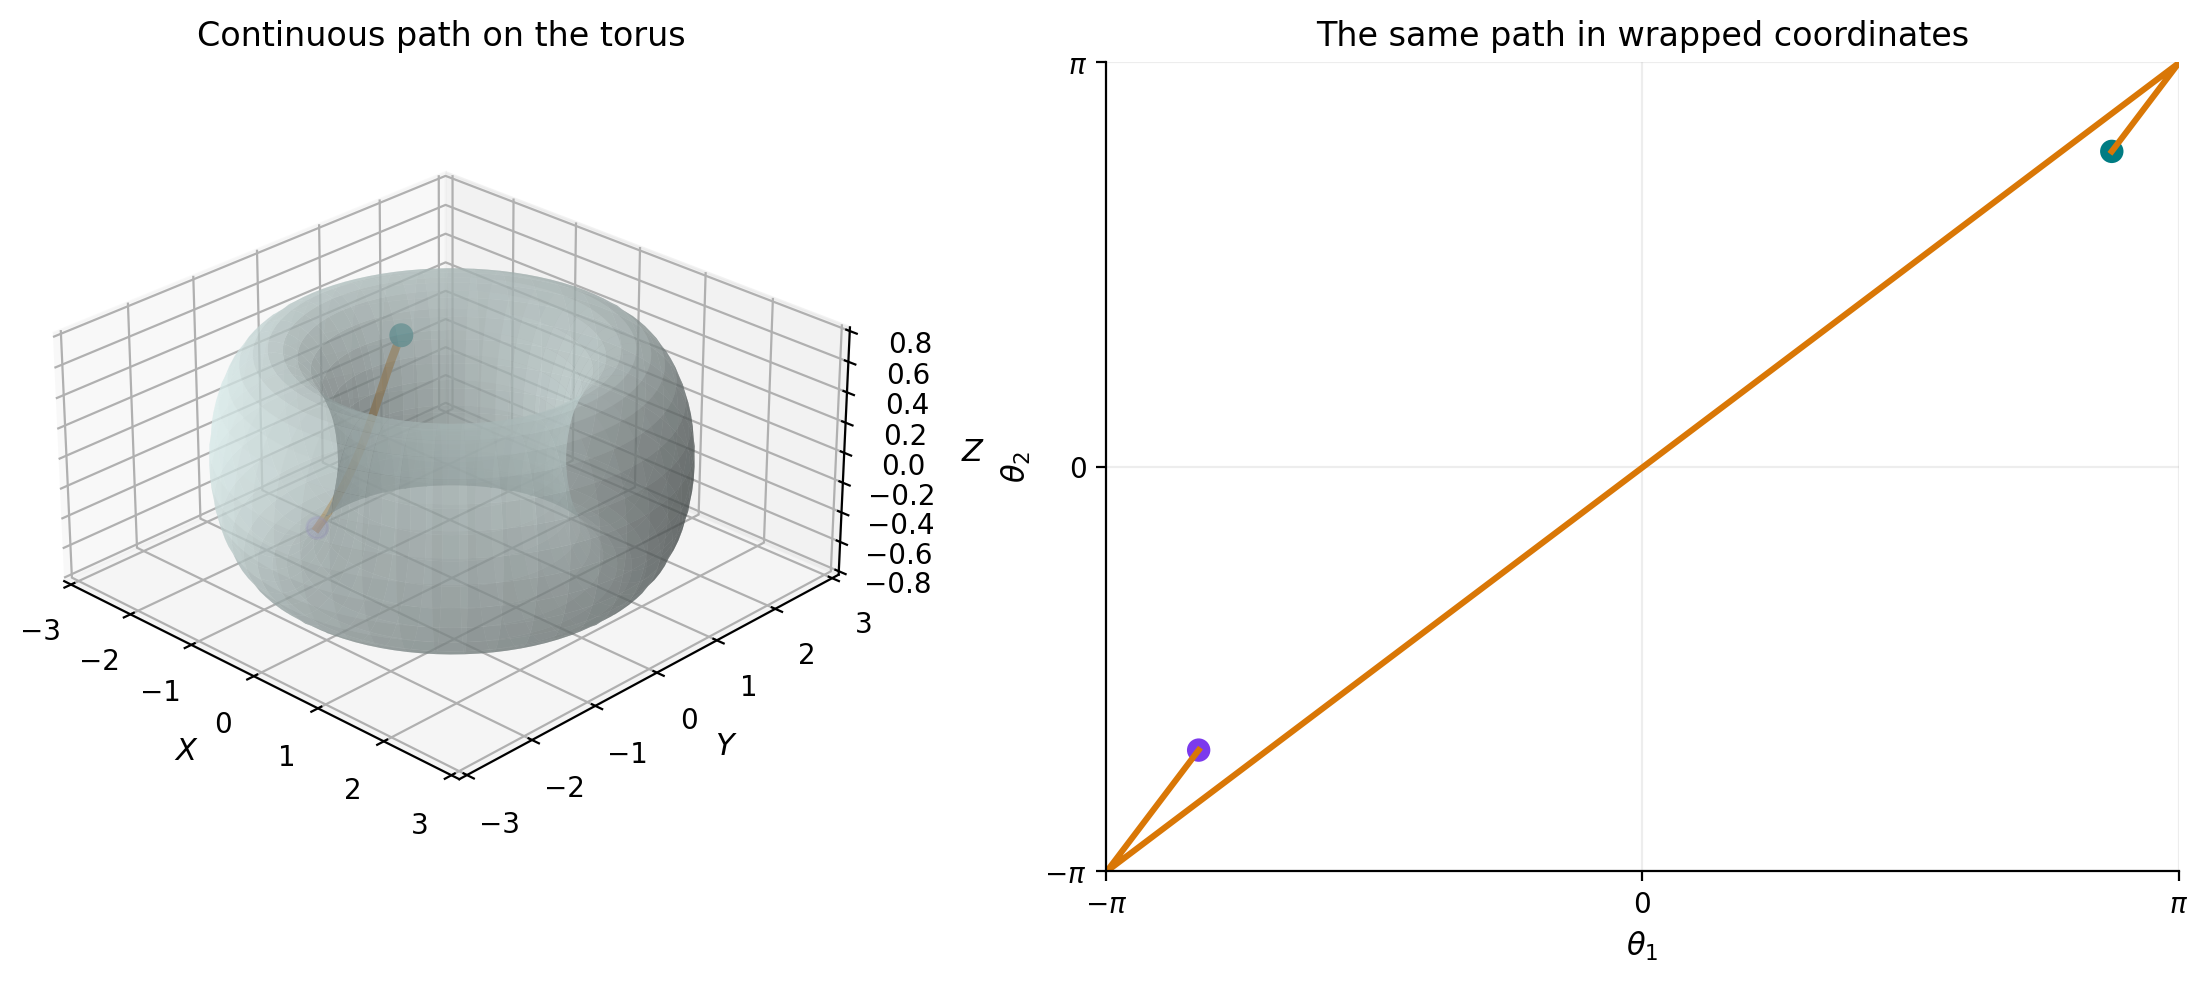

In [2]:
def embed_torus(angles, major_radius=2.0, minor_radius=0.72):
    theta = angles[..., 0]
    phi = angles[..., 1]
    radius = major_radius + minor_radius * np.cos(phi)
    return np.stack([
        radius * np.cos(theta),
        radius * np.sin(theta),
        minor_radius * np.sin(phi),
    ], axis=-1)


theta_grid = np.linspace(-np.pi, np.pi, 90)
phi_grid = np.linspace(-np.pi, np.pi, 55)
Theta, Phi = np.meshgrid(theta_grid, phi_grid)
surface = embed_torus(np.stack([Theta, Phi], axis=-1))
embedded_path = embed_torus(np.asarray(path))
embedded_endpoints = embed_torus(np.asarray(jnp.stack([x, y])))

fig = plt.figure(figsize=(11.5, 4.8), constrained_layout=True)
ax_torus = fig.add_subplot(1, 2, 1, projection="3d")
ax_angles = fig.add_subplot(1, 2, 2)

ax_torus.plot_surface(
    surface[..., 0], surface[..., 1], surface[..., 2],
    color="#D9ECEB", alpha=0.55, linewidth=0, antialiased=True,
)
ax_torus.plot(*embedded_path.T, color="#D97706", linewidth=3.0)
ax_torus.scatter(*embedded_endpoints.T, color=["#007C83", "#7C3AED"], s=58)
ax_torus.set(title="Continuous path on the torus", xlabel="$X$", ylabel="$Y$", zlabel="$Z$")
ax_torus.set_box_aspect((1, 1, 0.5))
ax_torus.view_init(elev=27, azim=-46)

ax_angles.plot(path[:, 0], path[:, 1], color="#D97706", linewidth=2.2)
ax_angles.scatter([x[0], y[0]], [x[1], y[1]], color=["#007C83", "#7C3AED"], s=55)
ax_angles.set(
    title="The same path in wrapped coordinates",
    xlabel=r"$\theta_1$",
    ylabel=r"$\theta_2$",
    xlim=(-np.pi, np.pi),
    ylim=(-np.pi, np.pi),
    xticks=[-np.pi, 0.0, np.pi],
    yticks=[-np.pi, 0.0, np.pi],
    xticklabels=[r"$-\pi$", "$0$", r"$\pi$"],
    yticklabels=[r"$-\pi$", "$0$", r"$\pi$"],
)
ax_angles.grid(alpha=0.22)

plt.show()

The broken appearance in the coordinate square is the expected effect of
choosing one representative for each periodic angle. `Torus.log` selects the
short branch automatically, and `Torus.exp` wraps every intermediate point.

## What to try next

- Move one endpoint until a coordinate difference is exactly $\pi$.
- Plot several tangent directions from the same point.
- Use `Product` to combine a torus state with a sphere or matrix geometry.